# Dataset Pipeline & PyTorch DataLoader Validation

This notebook validates the multi-modal dataset pipeline used to train the solar power forecasting model.  
It exercises `build_datasets()` from the `solar_forecast.dataset` module, inspects batch shapes and dtypes,  
verifies normalisation statistics, and visualises sample input windows.

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import sys, os
SF = os.path.abspath('../solar_forecast')
if SF not in sys.path:
    sys.path.insert(0, SF)

import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

DATA = Path('../solar_forecast/data')
CKPT = DATA / 'checkpoints'
FIG  = Path('figures')
FIG.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Setup complete.')

Setup complete.


## 1. Build Datasets

In [2]:
from dataset import build_datasets, LSTM_FEATURES, MET_FEATURES, WINDOW

print(f'LSTM input features : {LSTM_FEATURES}')
print(f'Met  input features : {MET_FEATURES}')
print(f'Input window length : {WINDOW} hours')

train_ds, val_ds, test_ds, stats, df = build_datasets(
    str(DATA / 'pune_500kw_hourly.csv'),
    str(DATA / 'satellite_patches.npz'),
)

print(f'\nSplit sizes:')
print(f'  Train : {len(train_ds):5d} samples  (Jan–Aug)')
print(f'  Val   : {len(val_ds):5d} samples  (Sep–Oct)')
print(f'  Test  : {len(test_ds):5d} samples  (Nov–Dec)')

LSTM input features : ['power_kw', 'ghi', 'temp_air', 'humidity']
Met  input features : ['temp_air', 'humidity', 'wind_speed', 'cloud_cover', 'zenith_deg']
Input window length : 24 hours

Split sizes:
  Train :  5808 samples  (Jan–Aug)
  Val   :  1464 samples  (Sep–Oct)
  Test  :  1463 samples  (Nov–Dec)


## 2. Sample Batch Shape Inspection

In [3]:
import torch
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

batch = next(iter(train_loader))
x_ts, x_met, x_img, y, y_raw = batch

print('Batch tensor inspection (train, batch_size=32):')
print(f'  x_ts  : shape={str(tuple(x_ts.shape)):<18} dtype={x_ts.dtype}  '
      f'range=[{x_ts.min():.3f}, {x_ts.max():.3f}]')
print(f'  x_met : shape={str(tuple(x_met.shape)):<18} dtype={x_met.dtype}  '
      f'range=[{x_met.min():.3f}, {x_met.max():.3f}]')
print(f'  x_img : shape={str(tuple(x_img.shape)):<18} dtype={x_img.dtype}  '
      f'range=[{x_img.min():.3f}, {x_img.max():.3f}]')
print(f'  y     : shape={str(tuple(y.shape)):<18} dtype={y.dtype}  '
      f'range=[{y.min():.3f}, {y.max():.3f}]  (normalised)')
print(f'  y_raw : shape={str(tuple(y_raw.shape)):<18} dtype={y_raw.dtype}  '
      f'range=[{y_raw.min():.1f}, {y_raw.max():.1f}] kW')

Batch tensor inspection (train, batch_size=32):
  x_ts  : shape=(32, 24, 6)        dtype=torch.float32  range=[-2.752, 2.590]
  x_met : shape=(32, 5)            dtype=torch.float32  range=[-1.780, 2.263]
  x_img : shape=(32, 3, 64, 64)    dtype=torch.float32  range=[0.000, 0.922]
  y     : shape=(32,)              dtype=torch.float32  range=[-0.766, 1.814]  (normalised)
  y_raw : shape=(32,)              dtype=torch.float32  range=[0.0, 334.8] kW


## 3. Met Feature Z-Score Distributions by Split

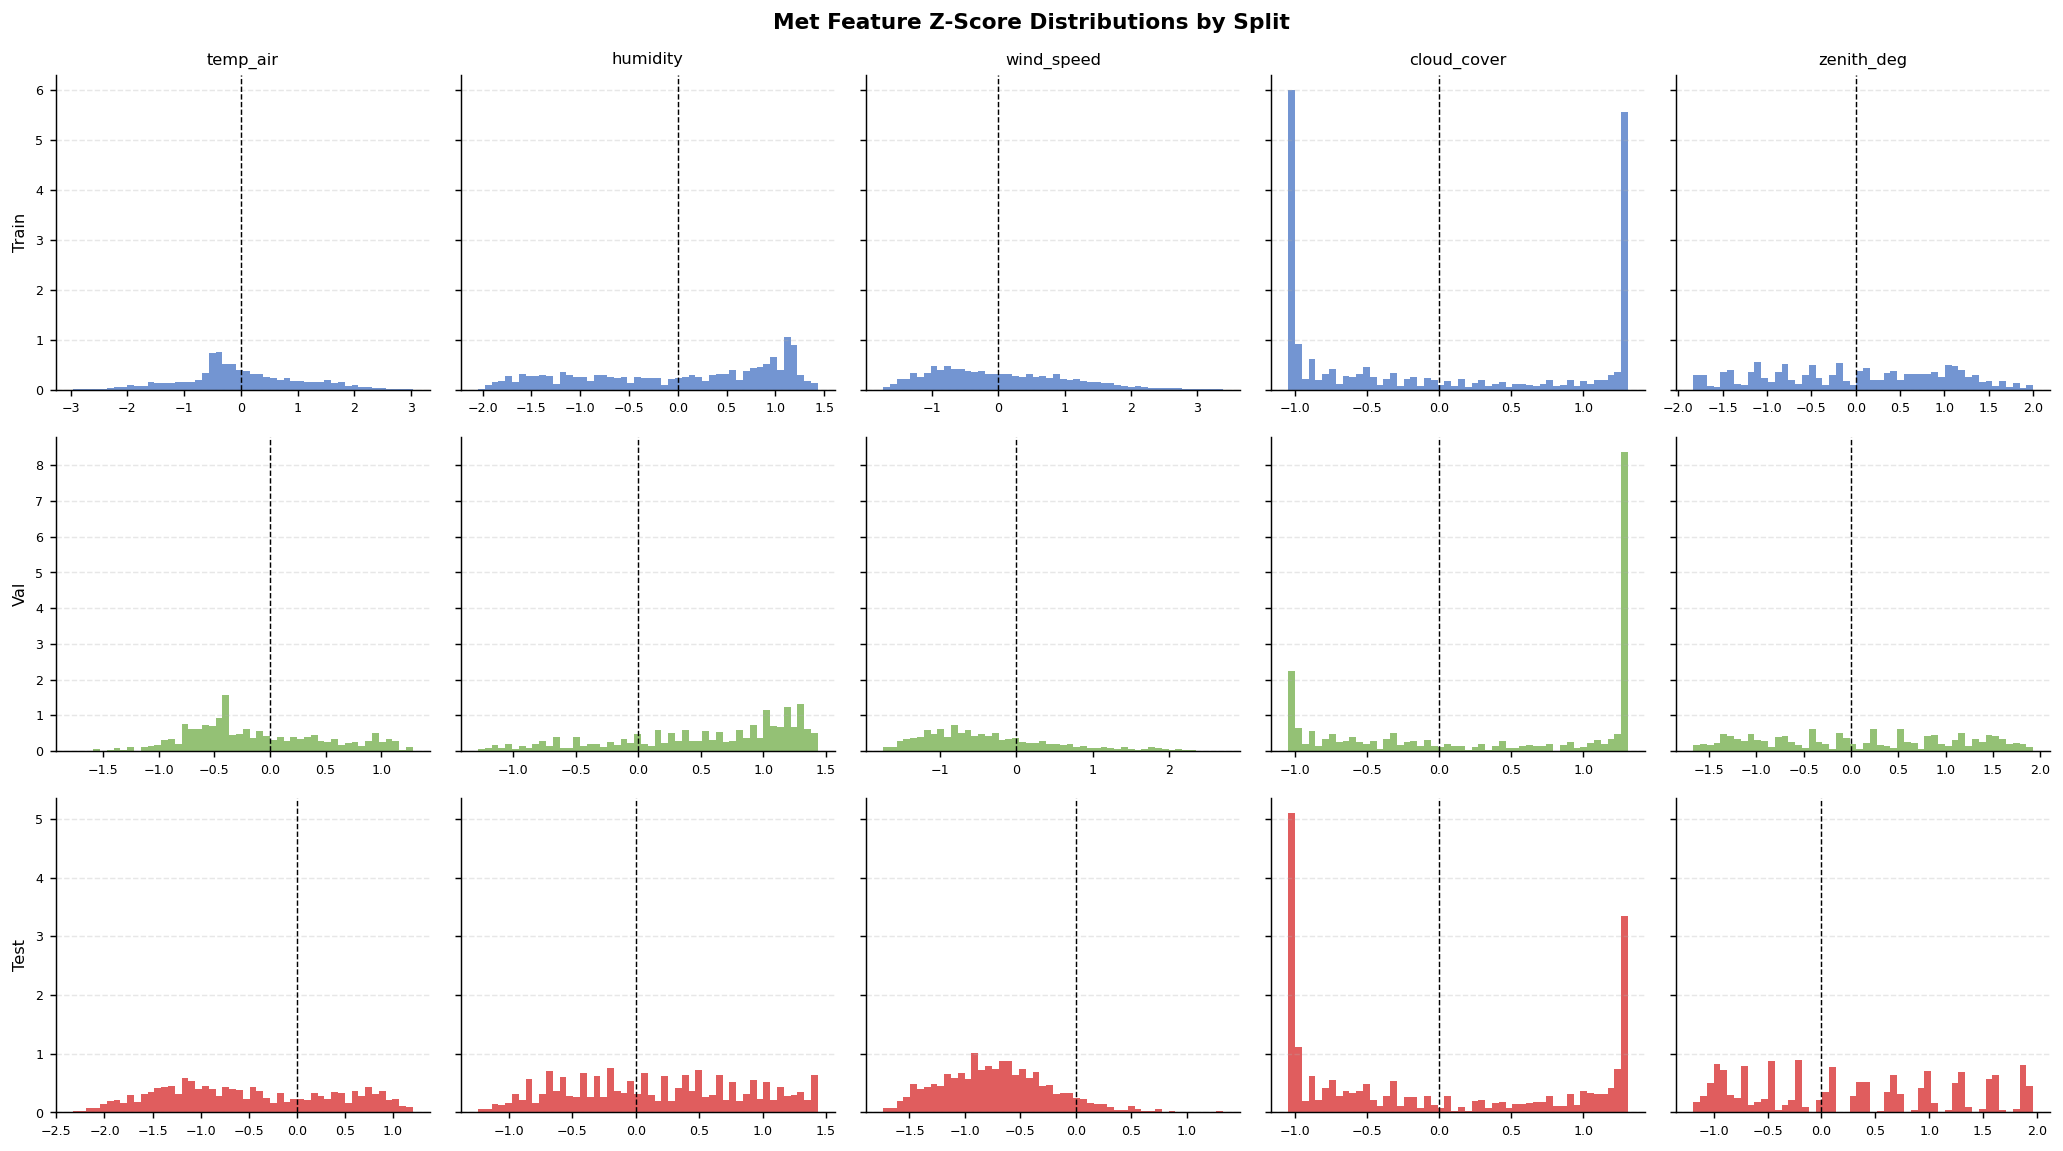

Saved: dataset_met_distributions.png


In [4]:
# Collect all met features from each split
def collect_met(ds):
    loader = DataLoader(ds, batch_size=512, shuffle=False)
    parts = []
    for batch in loader:
        parts.append(batch[1].numpy())
    return np.concatenate(parts, axis=0)

met_train = collect_met(train_ds)
met_val   = collect_met(val_ds)
met_test  = collect_met(test_ds)

n_feat = len(MET_FEATURES)
fig, axes = plt.subplots(3, n_feat, figsize=(16, 9), sharey='row')
fig.suptitle('Met Feature Z-Score Distributions by Split', fontsize=12, fontweight='bold')

SPLIT_DATA  = [('Train', met_train, '#4472C4'),
               ('Val',   met_val,   '#70AD47'),
               ('Test',  met_test,  '#D62728')]

for row, (split_name, arr, clr) in enumerate(SPLIT_DATA):
    for col, feat in enumerate(MET_FEATURES):
        ax = axes[row, col]
        ax.hist(arr[:, col], bins=50, color=clr, alpha=0.75, density=True, edgecolor='none')
        ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_title(feat, fontsize=9) if row == 0 else None
        ax.set_ylabel(split_name, fontsize=9) if col == 0 else None
        ax.tick_params(labelsize=7)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
fig.savefig(FIG / 'dataset_met_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: dataset_met_distributions.png')

## 4. Target Power Distributions by Split

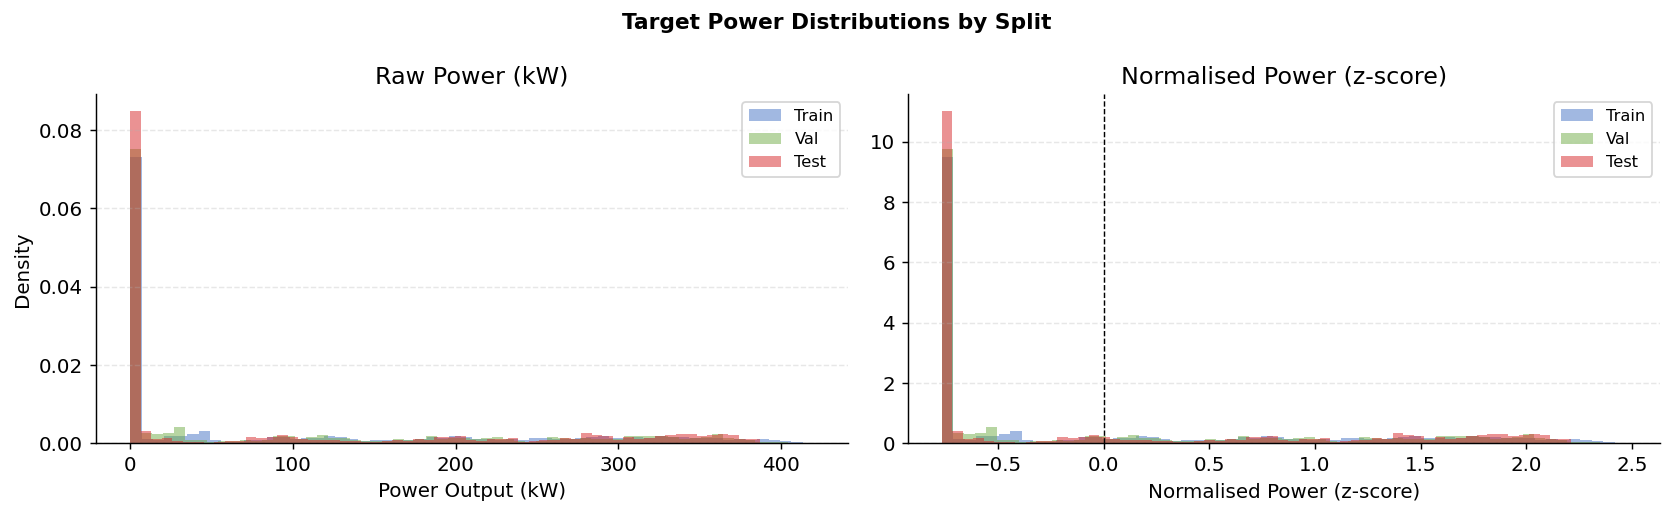

Saved: dataset_target_distributions.png


In [5]:
def collect_targets(ds):
    loader = DataLoader(ds, batch_size=512, shuffle=False)
    y_norm, y_raw = [], []
    for batch in loader:
        y_norm.append(batch[3].numpy())
        y_raw.append(batch[4].numpy())
    return np.concatenate(y_norm), np.concatenate(y_raw)

yn_tr, yr_tr = collect_targets(train_ds)
yn_vl, yr_vl = collect_targets(val_ds)
yn_ts, yr_ts = collect_targets(test_ds)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Target Power Distributions by Split', fontsize=12, fontweight='bold')

# Raw kW
for name, arr, clr in [('Train', yr_tr, '#4472C4'),
                        ('Val',   yr_vl, '#70AD47'),
                        ('Test',  yr_ts, '#D62728')]:
    axes[0].hist(arr, bins=60, alpha=0.5, color=clr, label=name,
                 density=True, edgecolor='none')
axes[0].set_xlabel('Power Output (kW)')
axes[0].set_ylabel('Density')
axes[0].set_title('Raw Power (kW)')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Normalised
for name, arr, clr in [('Train', yn_tr, '#4472C4'),
                        ('Val',   yn_vl, '#70AD47'),
                        ('Test',  yn_ts, '#D62728')]:
    axes[1].hist(arr, bins=60, alpha=0.5, color=clr, label=name,
                 density=True, edgecolor='none')
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Normalised Power (z-score)')
axes[1].set_title('Normalised Power (z-score)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
fig.savefig(FIG / 'dataset_target_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: dataset_target_distributions.png')

## 5. LSTM Input Window Visualisation — 5 Test Samples

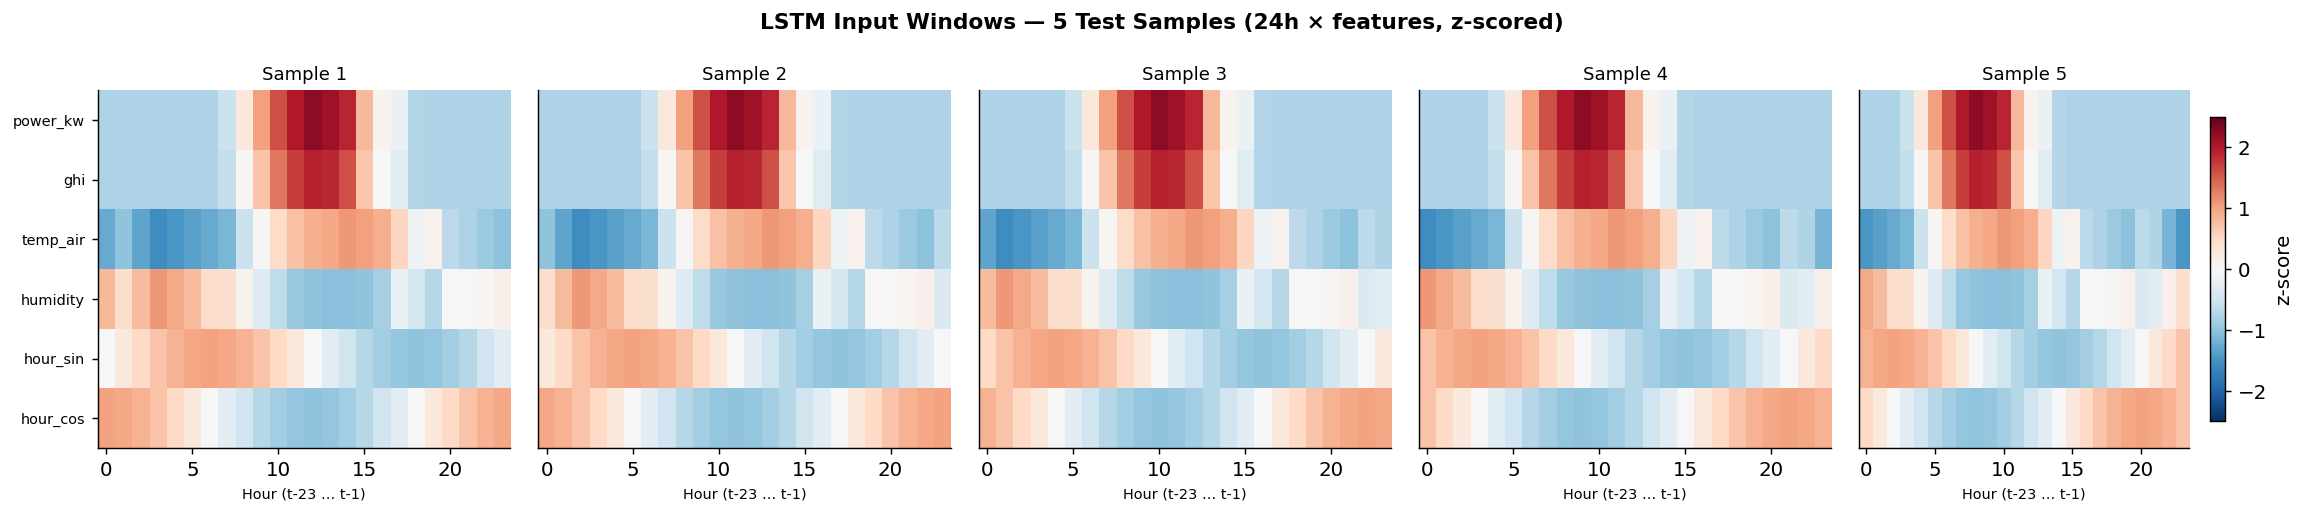

Saved: dataset_lstm_windows.png


In [6]:
test_loader_vis = DataLoader(test_ds, batch_size=5, shuffle=False)
batch_vis = next(iter(test_loader_vis))
x_ts_vis = batch_vis[0].numpy()   # (5, 24, n_feat)

n_feat_ts = x_ts_vis.shape[-1]
all_feats = LSTM_FEATURES + ['hour_sin', 'hour_cos']
feat_labels = all_feats[:n_feat_ts]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('LSTM Input Windows — 5 Test Samples (24h × features, z-scored)',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes):
    im = ax.imshow(x_ts_vis[i].T, aspect='auto', cmap='RdBu_r',
                   vmin=-2.5, vmax=2.5)
    ax.set_title(f'Sample {i+1}', fontsize=10)
    ax.set_xlabel('Hour (t-23 … t-1)', fontsize=8)
    if i == 0:
        ax.set_yticks(range(n_feat_ts))
        ax.set_yticklabels(feat_labels, fontsize=8)
    else:
        ax.set_yticks([])

fig.colorbar(im, ax=axes[-1], label='z-score', shrink=0.85)
plt.tight_layout()
fig.savefig(FIG / 'dataset_lstm_windows.png', bbox_inches='tight')
plt.show()
print('Saved: dataset_lstm_windows.png')


## 6. Normalisation Statistics

In [7]:
with open(DATA / 'norm_stats.json') as f:
    ns = json.load(f)

print('LSTM features:')
for feat, mu, sd in zip(ns['lstm_features'], ns['lstm_mean'], ns['lstm_std']):
    print(f'  {feat:<15}  mean={mu:8.3f}   std={sd:8.3f}')

print('\nMet features:')
for feat, mu, sd in zip(ns['met_features'], ns['met_mean'], ns['met_std']):
    print(f'  {feat:<15}  mean={mu:8.3f}   std={sd:8.3f}')

print(f'\nTarget (power_kw):  mean={ns["target_mean"]:.3f}   std={ns["target_std"]:.3f}')

LSTM features:
  power_kw         mean=  99.472   std= 129.764
  ghi              mean= 239.477   std= 312.872
  temp_air         mean=  25.021   std=   5.204
  humidity         mean=  62.497   std=  26.128

Met features:
  temp_air         mean=  25.021   std=   5.204
  humidity         mean=  62.497   std=  26.128
  wind_speed       mean=   2.898   std=   1.667
  cloud_cover      mean=   0.444   std=   0.424
  zenith_deg       mean=  86.907   std=  45.006

Target (power_kw):  mean=99.472   std=129.776
